In [2]:
import pandas as pd
df = pd.read_csv("/content/Titanic.csv")
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.shape

(891, 12)

In [6]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [11]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [12]:
df.columns = df.columns.str.strip()              # extra spaces remove
df.columns = df.columns.str.lower()              # lowercase
df.columns = df.columns.str.replace(" ", "_")    # space -> underscore

df.columns

Index(['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp',
       'parch', 'ticket', 'fare', 'cabin', 'embarked'],
      dtype='object')

In [13]:
df["age"] = df["age"].fillna(df["age"].mean())


In [15]:
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

In [18]:
df["cabin"].head(10)

,cabin
0,NaN
1,C85
2,NaN
3,C123
4,NaN
5,NaN
6,E46
7,NaN
8,NaN
9,NaN


In [19]:
# cabin column has maximum number of null value So we easily drop it..
df.drop("cabin", axis=1, inplace=True)


In [20]:
df.head(10)

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.000000,0,0,17463,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.000000,0,2,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.000000,1,0,237736,30.0708,C


In [21]:
df.shape

(891, 11)

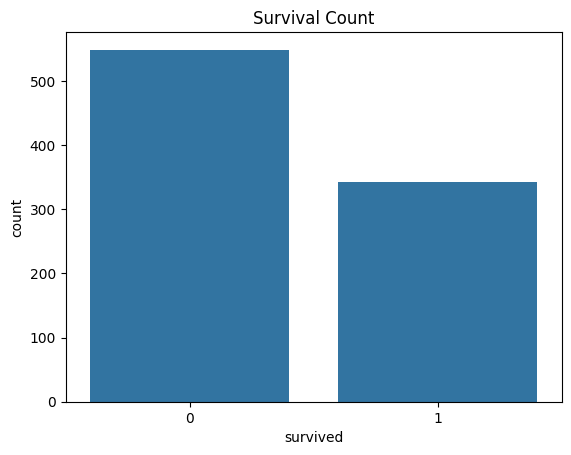

In [23]:
# required visualizations..
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="survived")
plt.title("Survival Count")
plt.show()

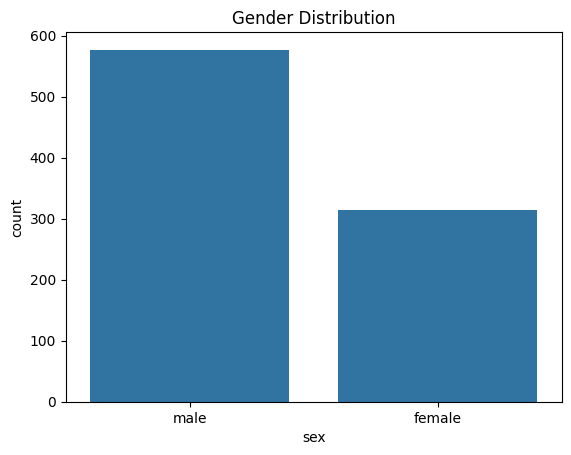

In [25]:
sns.countplot(data=df, x="sex")
plt.title("Gender Distribution")
plt.show()


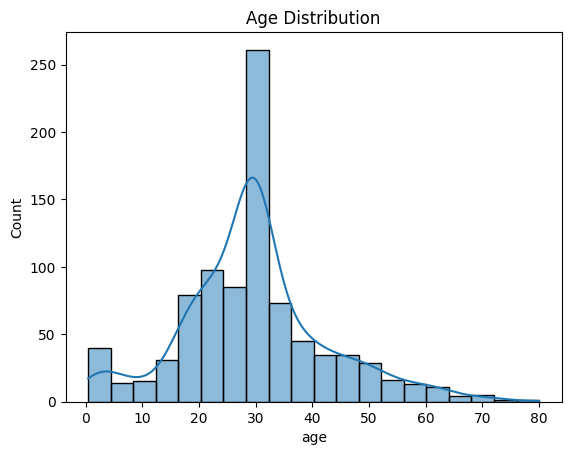

In [27]:
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

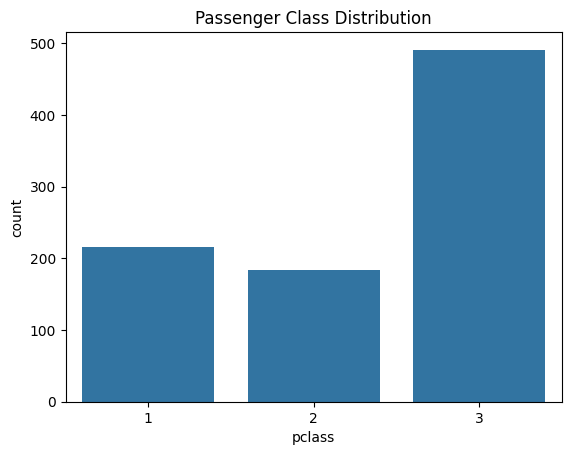

In [28]:
sns.countplot(data=df, x="pclass")
plt.title("Passenger Class Distribution")
plt.show()

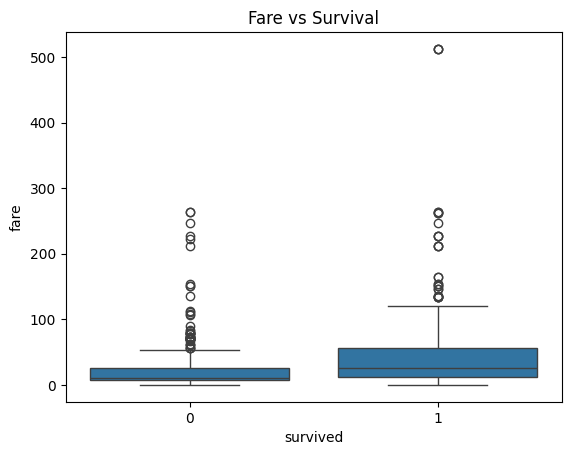

In [29]:
sns.boxplot(data=df, x="survived", y="fare")
plt.title("Fare vs Survival")
plt.show()

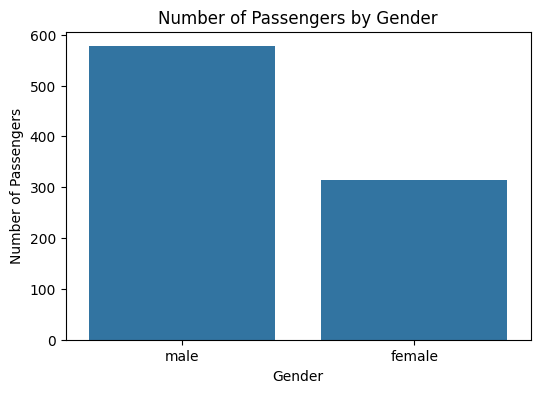

In [32]:
# Q1. Create a countplot to show the number of passengers by gender.
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="sex")

plt.title("Number of Passengers by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

/tmp/ipykernel_2034/168004279.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x="pclass",palette=["red", "green", "blue"])


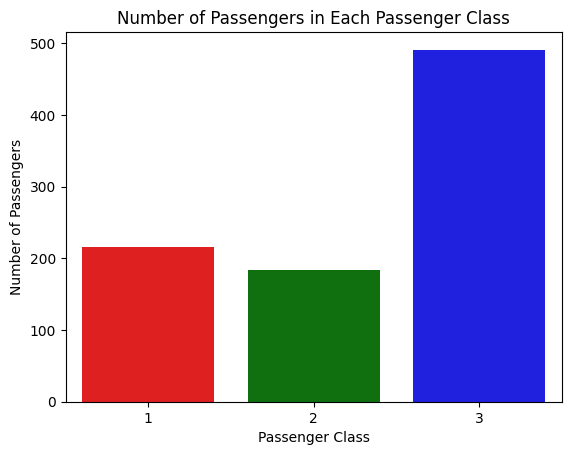

In [33]:
# Q2. Create a bar chart to show the number of passengers in each passenger class using different colors.
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df,x="pclass",palette=["red", "green", "blue"])

plt.title("Number of Passengers in Each Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

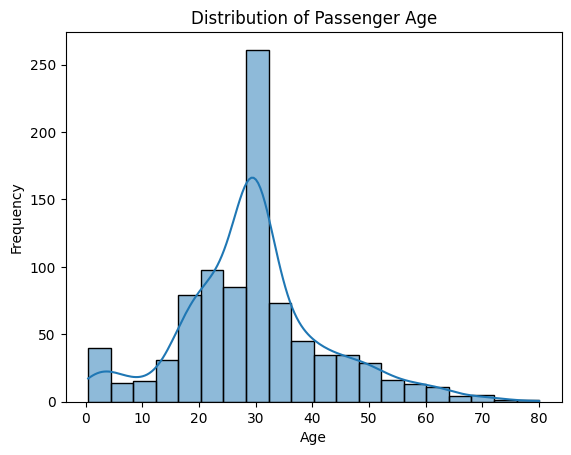

In [34]:
#Q3. Create a histogram to show the distribution of passenger age.\
sns.histplot(data=df, x="age", bins =20, kde=True)

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

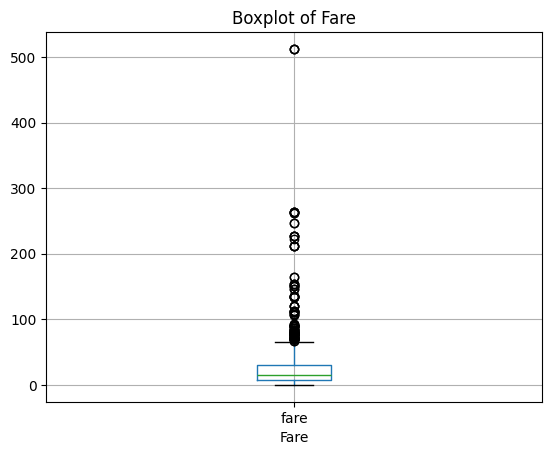

In [35]:
#Q4. Create a boxplot to detect outliers in the fare column.
df.boxplot(column="fare")

plt.title("Boxplot of Fare")
plt.xlabel("Fare")

plt.show()


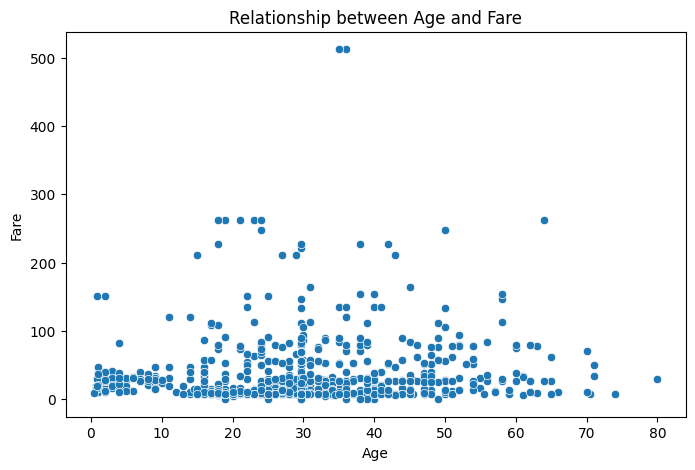

In [37]:
'''Q5. Create a scatterplot to

 a. show the relationship between age and fare.

 b. analyze the relationship between family size (SibSp + Parch) and fare.'''

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="age", y="fare")

plt.title("Relationship between Age and Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

In [42]:
# ques 5- b
df["Family_Size"] = df["sibsp"] + df["parch"]

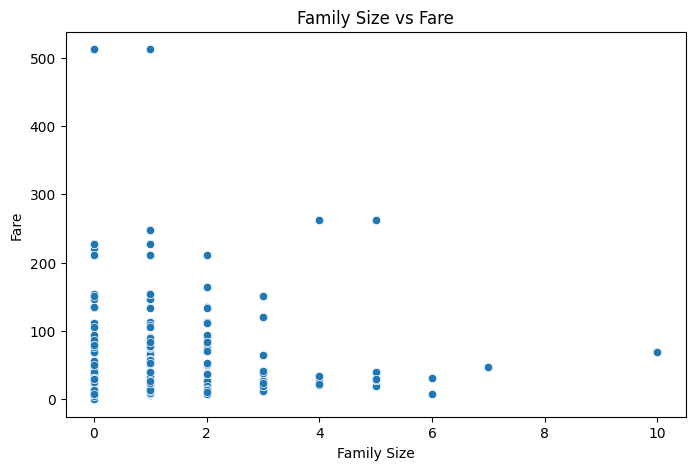

In [44]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="Family_Size", y="fare")

plt.title("Family Size vs Fare")
plt.xlabel("Family Size")
plt.ylabel("Fare")

plt.show()

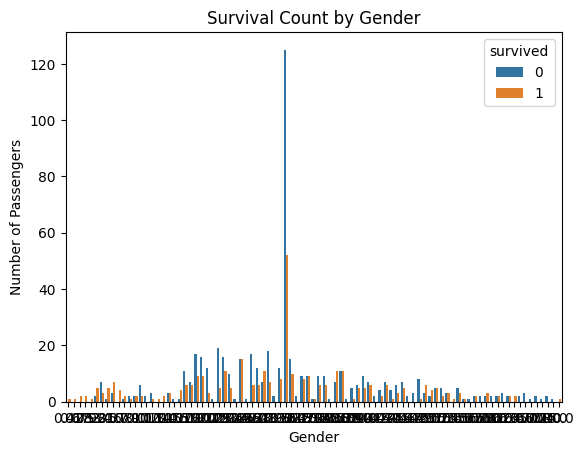

In [45]:
# Q6. Create a countplot to show survival count by gender.
sns.countplot(data =df, x ="age", hue = "survived" )
plt.title("Survival Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()


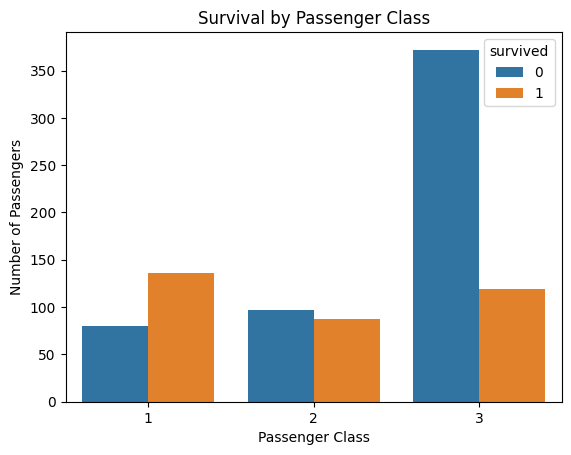

In [46]:
#Q7. Create a bar chart to show survival by passenger class.
sns.countplot(data =df, x ="pclass", hue = "survived" )
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

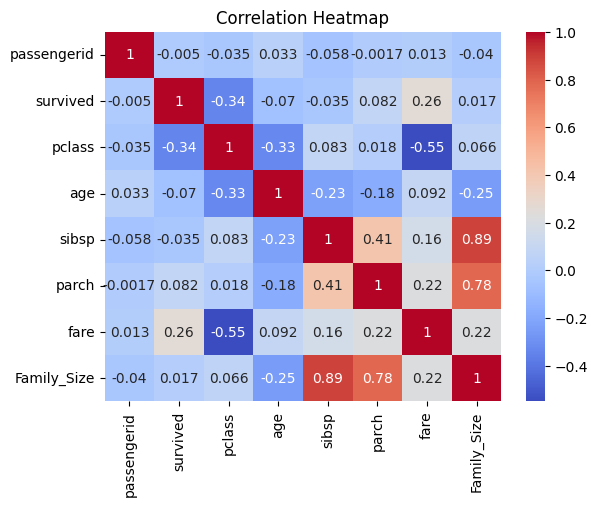

In [48]:
#Q8. Create a heatmap to show correlation between numerical variables.
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [50]:
#Q9. Identify which passenger class paid the highest fare on average.
avg_fare = df.groupby("pclass")["fare"].mean()

print(avg_fare)

pclass
1    84.154687
2    20.662183
3    13.675550
Name: fare, dtype: float64


In [51]:


print(avg_fare.idxmax())
print(avg_fare.max())

1
84.1546875


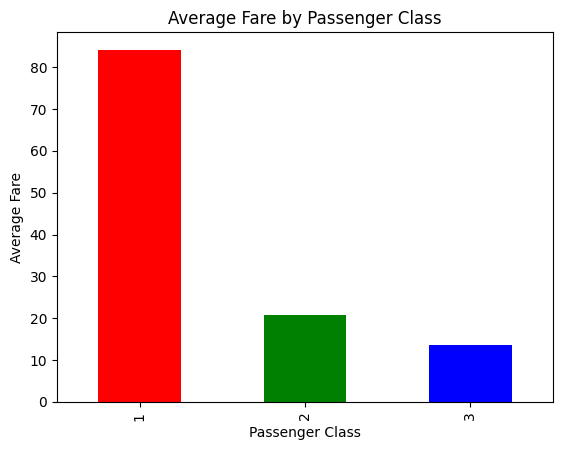

In [52]:
import matplotlib.pyplot as plt

avg_fare.plot(kind="bar", color=["red", "green", "blue"])

plt.title("Average Fare by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Average Fare")

plt.show()

1. The dataset contains more male passengers than female passengers.
2. Female passengers had a higher survival rate than male passengers.
3. Most passengers belonged to Passenger Class 3, while Passenger Class 1 had the fewest passengers.
4. Passenger Class 1 paid the highest average fare, followed by Class 2 and Class 3.
5. The age distribution shows that most passengers were young to middle-aged, with fewer children and elderly passengers.